In [1]:
!pip install numpy matplotlib scikit-learn pandas openpyxl
!pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#file = pd.read_excel("/home/edu/projetos/rede-neural/datasets/tabela_distancia_consumo.xlsx").to_numpy()
#
#valor = file[:, 0]
#rotulo = file[:, 1]

valor = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
rotulo = np.array([3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
valor, rotulo

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([ 3,  6,  9, 12, 15, 18, 21, 24, 27, 30]))

In [4]:
def calcularPrevisao(w, x, b):
    return w * x + b


def loss(Y, y):
    return Y - y


def correcaoW(w, a, erro, x):
    return w - (a * erro * x)


def correcaoB(b, a, erro):
    return b - (a * erro)


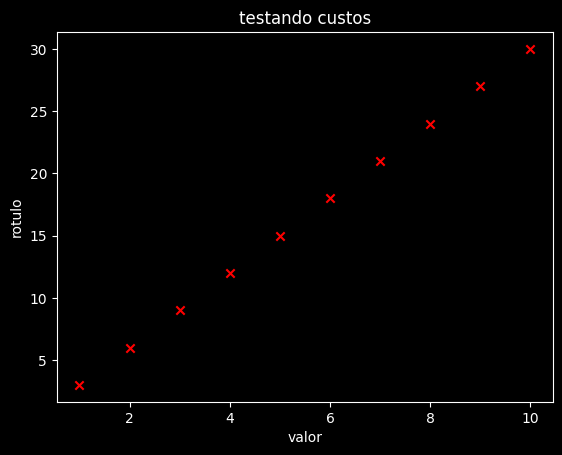

In [5]:
plt.scatter(valor, rotulo, marker='x', c='r')
plt.title('testando custos')
plt.ylabel('rotulo')
plt.xlabel('valor')
plt.show()

In [10]:
def modelo(x, y, w, b, taxa_aprendizado=0.01):
    m = x.shape[0]
    f_wb = np.zeros(m)
    generation = 10

    for gen in range(generation):
        f_wb = np.zeros(m)
        somatorio_erro_w = 0
        somatorio_erro_b = 0

        for i in range(m):
            f_wb[i] = w * x[i] + b

        for i in range(m):
            somatorio_erro_w += (f_wb[i] - y[i])

        for i in range(m):
            somatorio_erro_b += (f_wb[i] - y[i])

        for i in range(m):
            media_erro_w = (somatorio_erro_w / m) * x[i]

        media_erro_b = somatorio_erro_b / m

        print(f"{media_erro_w:.1f}")
        print(f"{media_erro_b:.1f}")
        w = w - (taxa_aprendizado * media_erro_w)
        b = b - (taxa_aprendizado * media_erro_b)
        print(f"{w:.2f}")
        print(f"{b:.2f}")

    return f_wb


f_wb_calculado = modelo(valor, rotulo, 0, 0)
f_wb_calculado


-165.0
-16.5
1.65
0.17
-72.6
-7.3
2.38
0.24
-31.9
-3.2
2.70
0.27
-14.1
-1.4
2.84
0.28
-6.2
-0.6
2.90
0.29
-2.7
-0.3
2.93
0.29
-1.2
-0.1
2.94
0.29
-0.5
-0.1
2.94
0.29
-0.2
-0.0
2.94
0.29
-0.1
-0.0
2.95
0.29


array([ 3.23906805,  6.18367537,  9.12828269, 12.07289001, 15.01749733,
       17.96210465, 20.90671197, 23.85131929, 26.79592661, 29.74053393])

In [ ]:
plt.plot(valor, f_wb_calculado, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()


In [ ]:
def calcular_custo(tamanho, previsao, valorReal):
    custo_somado = 0
    for i in range(tamanho):
        custo_somado += (previsao[i] - valorReal[i]) ** 2

    custo_final = custo_somado / (2 * tamanho)
    return custo_final


custo = calcular_custo(m, f_wb_calculado, rotulo)
f_wb_calculado_com_custo = f_wb_calculado.copy()

for i in range(m):
    f_wb_calculado_com_custo[i] -= custo

plt.plot(valor, f_wb_calculado_com_custo, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()

print(f_wb_calculado)
print()
print(f_wb_calculado_com_custo)



In [ ]:
#IA
def treinar_modelo(x, y_real, w, b, alpha, epocas):
    m = len(x)

    for epoca in range(epocas):
        soma_dw = 0
        soma_db = 0

        # 1. Acumula o gradiente para todos os dados
        for i in range(m):
            previsao = w * x[i] + b
            erro = previsao - y_real[i]

            soma_dw += erro * x[i]
            soma_db += erro

        # 2. Calcula a média do gradiente (as derivadas)
        dj_dw = soma_dw / m
        dj_db = soma_db / m

        # 3. Atualiza os pesos (Regra da sua imagem)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        # Opcional: imprimir o custo a cada 100 iterações para ver se está caindo
    return w, b

In [ ]:
w_novo, b_novo = treinar_modelo(valor, rotulo, w, b, 0.1, 300)
w_novo = w_novo.item()
b_novo = b_novo.item()

novo_modelo = modelo(valor, w_novo, b_novo)
plt.plot(valor, novo_modelo, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()



In [ ]:
w_novo * 900 + b_novo